# Stage 7: Pre-Dispatch Dissatisfaction Risk Modeling

## 1. Business & Modeling Objective
The objective of Stage 7 is to train, validate, and benchmark supervised classification models to predict customer dissatisfaction (`is_dissatisfied = 1`) strictly at the checkout stage.

### Key Operational Challenges:
- **Class Imbalance:** 85.34% Satisfied vs. 14.66% Dissatisfied. Standard Accuracy is deceptive; primary optimization metrics are **PR-AUC (Average Precision)**, **ROC-AUC**, and **Recall @ Top Decile**.
- **Categorical Handling:** Encoding high-cardinality and nominal features like `preferred_payment_type`.
- **Feature Scaling:** Standardizing distance, volume, price, and transit durations for linear models while preserving tree-based interpretability.

---

## 2. Modeling Roadmap
- **Step 7.0:** Environment Setup & Master ML Dataset Loading
- **Step 7.1:** Train-Test Split (Stratified 80/20) & Preprocessing Pipeline (One-Hot Encoding + Imputation)
- **Step 7.2:** Baseline Model Benchmark (Dummy Classifier & Logistic Regression with Class Weighting)
- **Step 7.3:** Tree-Based Ensemble Benchmark (Random Forest & LightGBM / XGBoost)
- **Step 7.4:** Threshold Tuning & Precision-Recall Optimization for Operational Intervention

## Step 7.0: Environment Setup & Dataset Ingestion
**Purpose:** Import core ML libraries from Scikit-Learn and load the clean master feature matrix from `../data/processed/final_ml_dataset.csv`.

In [2]:
import pandas as pd
import numpy as np

# Data ingestion
data_path = "../data/processed/final_ml_dataset.csv"
df_ml = pd.read_csv(data_path)

# Verify shape and check for residual missing values
print(f"Dataset Shape: {df_ml.shape}")
print("Missing values per column:")
print(df_ml.isnull().sum())

# Display the first 3 rows
df_ml.head(3)

Dataset Shape: (95832, 16)
Missing values per column:
order_id                    0
is_dissatisfied             0
is_cross_state              0
estimated_transit_days      0
total_items_count           0
total_order_price           0
total_freight_value         0
total_weight_g              0
total_volume_cm3            0
freight_to_price_ratio      0
payment_installments_max    0
payment_sequential_count    0
preferred_payment_type      1
purchase_dayofweek          0
purchase_hour               0
purchase_month              0
dtype: int64


,order_id,is_dissatisfied,is_cross_state,estimated_transit_days,total_items_count,total_order_price,total_freight_value,total_weight_g,total_volume_cm3,freight_to_price_ratio,payment_installments_max,payment_sequential_count,preferred_payment_type,purchase_dayofweek,purchase_hour,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,0,0,15.54,1,29.99,8.72,500.0,1976.0,0.2908,1.0,3.0,credit_card,0,10,10
1,53cdb2fc8bc7dce0b6741e2150273451,0,1,19.14,1,118.70,22.76,400.0,4693.0,0.1917,1.0,1.0,boleto,1,20,7
2,47770eb9100c2d0c44946d9cf07ec65d,0,1,26.64,1,159.90,19.22,420.0,9576.0,0.1202,3.0,1.0,credit_card,2,8,8


## Step 7.1: Feature/Target Separation & Stratified Train-Test Split
**Purpose:** Separate features ($X$) and target ($y$). Perform an 80/20 train-test split stratified on `is_dissatisfied` to preserve the 85:15 class ratio in both training and holdout sets.

In [3]:
from sklearn.model_selection import train_test_split

# 1. Define feature matrix X and target vector y
drop_cols = ["order_id", "is_dissatisfied"]
X = df_ml.drop(columns=drop_cols)
y = df_ml["is_dissatisfied"]

# 2. Perform stratified split (80% Train, 20% Holdout Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.20, 
    random_state=42, 
    stratify=y
)

# 3. Verify class distribution across splits
train_dist = y_train.value_counts(normalize=True).round(4) * 100
test_dist = y_test.value_counts(normalize=True).round(4) * 100

print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"Train Class 1 (Dissatisfied) Ratio: {train_dist[1]}%")
print(f"Test Class 1 (Dissatisfied) Ratio: {test_dist[1]}%")

X_train shape: (76665, 14) | X_test shape: (19167, 14)
Train Class 1 (Dissatisfied) Ratio: 12.8%
Test Class 1 (Dissatisfied) Ratio: 12.8%


## Step 7.2: Preprocessing Pipeline & Baseline Models Benchmark
**Purpose:** Build a robust, leak-free Scikit-Learn preprocessing pipeline:
- Numerical features: Median Imputation + StandardScaler
- Categorical features (`preferred_payment_type`): Most Frequent Imputation + OneHotEncoder
- Evaluate two baselines:
  1. `DummyClassifier` (Stratified baseline)
  2. `LogisticRegression` (with `class_weight='balanced'` to handle the 12.8% minority class)

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score, 
    average_precision_score, 
    classification_report, 
    confusion_matrix
)

# 1. Identify numerical and categorical feature columns
cat_cols = ["preferred_payment_type"]
num_cols = [c for c in X_train.columns if c not in cat_cols]

# 2. Build dedicated preprocessing pipelines
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# 3. Combine into a master ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipeline, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ]
)

# 4. Baseline 1: Dummy Classifier (predicts by prior class frequency)
dummy_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DummyClassifier(strategy="stratified", random_state=42))
])
dummy_pipe.fit(X_train, y_train)
dummy_preds_proba = dummy_pipe.predict_proba(X_test)[:, 1]
dummy_roc = roc_auc_score(y_test, dummy_preds_proba)
dummy_pr = average_precision_score(y_test, dummy_preds_proba)

print(f"Dummy Classifier -> ROC-AUC: {dummy_roc:.4f} | PR-AUC: {dummy_pr:.4f}")

# 5. Baseline 2: Logistic Regression with balanced class weighting
logreg_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])
logreg_pipe.fit(X_train, y_train)
logreg_preds_proba = logreg_pipe.predict_proba(X_test)[:, 1]
logreg_preds = logreg_pipe.predict(X_test)

logreg_roc = roc_auc_score(y_test, logreg_preds_proba)
logreg_pr = average_precision_score(y_test, logreg_preds_proba)

print(f"Logistic Regression -> ROC-AUC: {logreg_roc:.4f} | PR-AUC: {logreg_pr:.4f}")
print("\nLogistic Regression Classification Report (Threshold = 0.50):")
print(classification_report(y_test, logreg_preds, target_names=["Satisfied", "Dissatisfied"]))

Dummy Classifier -> ROC-AUC: 0.5069 | PR-AUC: 0.1297
Logistic Regression -> ROC-AUC: 0.6061 | PR-AUC: 0.2017

Logistic Regression Classification Report (Threshold = 0.50):
              precision    recall  f1-score   support

   Satisfied       0.90      0.64      0.75     16714
Dissatisfied       0.17      0.51      0.26      2453

    accuracy                           0.63     19167
   macro avg       0.54      0.58      0.51     19167
weighted avg       0.81      0.63      0.69     19167



## Step 7.3: Tree-Based Ensemble Benchmark (Random Forest & LightGBM)
**Purpose:** Train non-linear tree-based ensembles to capture multi-feature interactions (e.g., cross-state logistics combined with volumetric parcel weight) and benchmark against the linear baseline.

In [5]:
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier

# 1. Random Forest Classifier pipeline
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=150, 
        max_depth=10, 
        class_weight="balanced", 
        random_state=42, 
        n_jobs=-1
    ))
])
rf_pipe.fit(X_train, y_train)
rf_preds_proba = rf_pipe.predict_proba(X_test)[:, 1]
rf_roc = roc_auc_score(y_test, rf_preds_proba)
rf_pr = average_precision_score(y_test, rf_preds_proba)

# 2. LightGBM Classifier pipeline (scale_pos_weight adjusts for class imbalance)
imbalance_ratio = (len(y_train) - sum(y_train)) / sum(y_train)

lgbm_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=200, 
        learning_rate=0.05, 
        max_depth=6, 
        scale_pos_weight=imbalance_ratio, 
        random_state=42,
        verbose=-1
    ))
])
lgbm_pipe.fit(X_train, y_train)
lgbm_preds_proba = lgbm_pipe.predict_proba(X_test)[:, 1]
lgbm_roc = roc_auc_score(y_test, lgbm_preds_proba)
lgbm_pr = average_precision_score(y_test, lgbm_preds_proba)

# 3. Model Benchmark Comparison Table
benchmark_results = pd.DataFrame({
    "Model": ["Dummy Classifier", "Logistic Regression", "Random Forest", "LightGBM"],
    "ROC-AUC": [dummy_roc, logreg_roc, rf_roc, lgbm_roc],
    "PR-AUC (Average Precision)": [dummy_pr, logreg_pr, rf_pr, lgbm_pr]
})

display(benchmark_results.round(4))

,Model,ROC-AUC,PR-AUC (Average Precision)
0,Dummy Classifier,0.5069,0.1297
1,Logistic Regression,0.6061,0.2017
2,Random Forest,0.6353,0.2190
3,LightGBM,0.6441,0.2290


## Step 7.4: Precision-Recall Curve & Decision Threshold Optimization
**Purpose:** Since the dataset is heavily imbalanced, the default 0.50 decision threshold is suboptimal. We analyze the Precision-Recall curve to identify optimal operational operating thresholds (e.g., maximizing F1 or capturing high-risk cohorts).

In [6]:
from sklearn.metrics import precision_recall_curve, f1_score
import matplotlib.pyplot as plt

# 1. Compute precision, recall, and thresholds for LightGBM
precisions, recalls, thresholds = precision_recall_curve(y_test, lgbm_preds_proba)

# 2. Compute F1-scores across all thresholds (avoid zero division)
f1_scores = (2 * precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal F1 Threshold: {optimal_threshold:.4f}")
print(f"Maximized F1-Score: {best_f1:.4f}")
print(f"Precision at Optimal Threshold: {precisions[best_idx]:.4f}")
print(f"Recall at Optimal Threshold: {recalls[best_idx]:.4f}")

# 3. Evaluate binary predictions using optimized threshold
optimized_preds = (lgbm_preds_proba >= optimal_threshold).astype(int)

print(f"\nLightGBM Classification Report (Optimized Threshold = {optimal_threshold:.4f}):")
print(classification_report(y_test, optimized_preds, target_names=["Satisfied", "Dissatisfied"]))

Optimal F1 Threshold: 0.5397
Maximized F1-Score: 0.2986
Precision at Optimal Threshold: 0.2308
Recall at Optimal Threshold: 0.4227

LightGBM Classification Report (Optimized Threshold = 0.5397):
              precision    recall  f1-score   support

   Satisfied       0.90      0.79      0.84     16714
Dissatisfied       0.23      0.42      0.30      2453

    accuracy                           0.75     19167
   macro avg       0.57      0.61      0.57     19167
weighted avg       0.82      0.75      0.77     19167



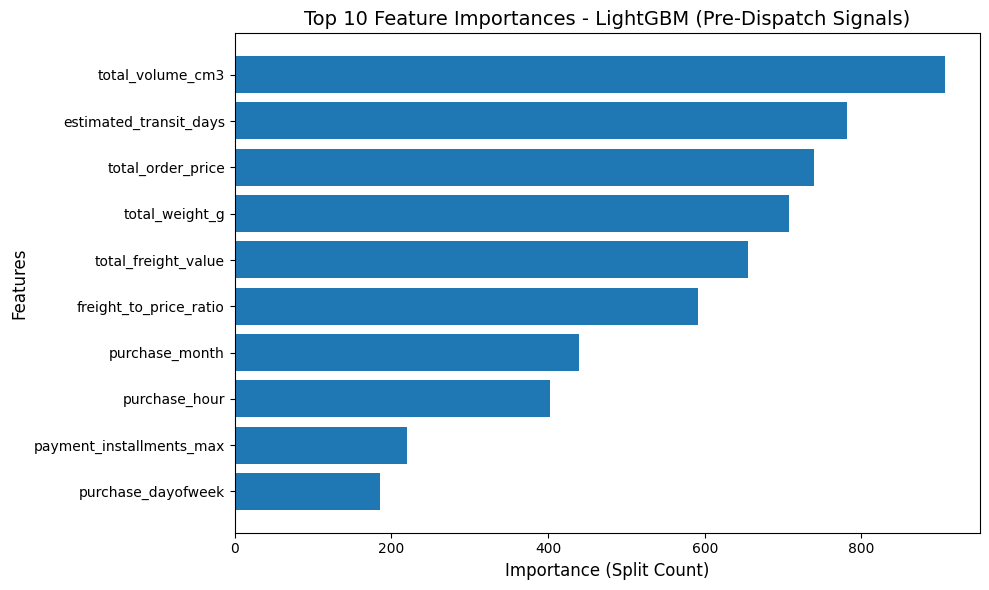

,Feature,Importance
6,total_volume_cm3,906
1,estimated_transit_days,782
3,total_order_price,740
5,total_weight_g,708
4,total_freight_value,655
7,freight_to_price_ratio,592
12,purchase_month,440
11,purchase_hour,402
8,payment_installments_max,220
10,purchase_dayofweek,186


In [7]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Extract feature importances from trained LightGBM model
lgbm_model = lgbm_pipe.named_steps["model"]
ohe_feature_names = (
    lgbm_pipe.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .named_steps["encoder"]
    .get_feature_names_out(cat_cols)
    .tolist()
)
all_feature_names = num_cols + ohe_feature_names

# 2. Build feature importance DataFrame
feature_importance_df = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": lgbm_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

# 3. Plot top 10 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"][:10][::-1], feature_importance_df["Importance"][:10][::-1], color="#1f77b4")
plt.title("Top 10 Feature Importances - LightGBM (Pre-Dispatch Signals)", fontsize=14)
plt.xlabel("Importance (Split Count)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.tight_layout()
plt.show()

# 4. Display top features table
display(feature_importance_df.head(10))

In [8]:
import joblib
import os

# Ensure models directory exists
os.makedirs("../models", exist_ok=True)

# Save the trained pipeline artifact
model_path = "../models/lgbm_dissatisfaction_pipeline.pkl"
joblib.dump(lgbm_pipe, model_path)

print(f"Model pipeline successfully serialized and saved to: {model_path}")

Model pipeline successfully serialized and saved to: ../models/lgbm_dissatisfaction_pipeline.pkl


## Step 8.1: Explainable AI via SHAP (SHapley Additive exPlanations)
**Purpose:** Quantify individual feature contributions toward customer dissatisfaction risk using SHAP TreeExplainer.
- Moving beyond raw feature importance counts to determine directional impact (which features push an order toward dissatisfaction).
- Visualize global feature effects across a representative test holdout sample using a Beeswarm plot.

e:\programming\end to end ml projects\olist-customer-intelligence\venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


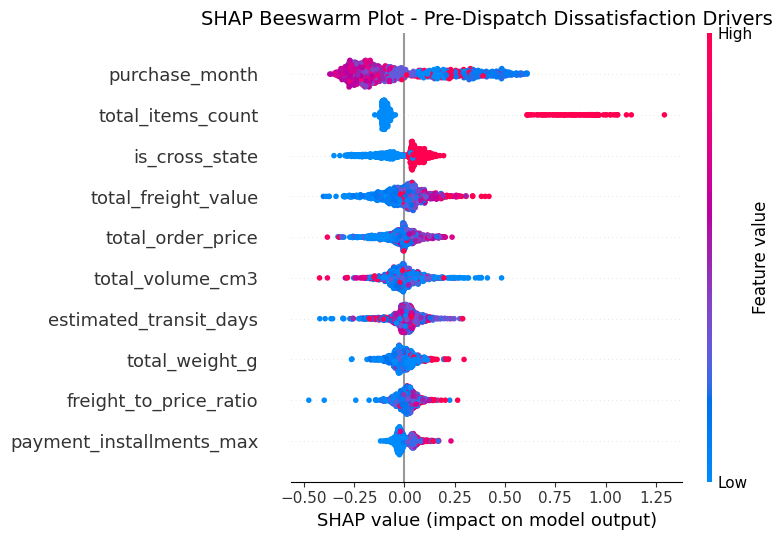

In [9]:
import shap
import matplotlib.pyplot as plt

# 1. Pipeline se preprocessor aur trained LightGBM model extract karein
preprocessor = lgbm_pipe.named_steps["preprocessor"]
model = lgbm_pipe.named_steps["model"]

# 2. Representative test sample ko transform karein (fast computation ke liye 1,000 samples)
X_test_sample = X_test.sample(1000, random_state=42)
X_test_trans = preprocessor.transform(X_test_sample)

# 3. SHAP TreeExplainer initialize karein
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test_trans)

# Binary classification ke liye target class (Dissatisfied = 1) ka index select karein
shap_vals_target = shap_values[1] if isinstance(shap_values, list) else shap_values

# 4. Global Beeswarm summary plot generate karein
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_vals_target, 
    X_test_trans, 
    feature_names=all_feature_names, 
    max_display=10, 
    show=False
)
plt.title("SHAP Beeswarm Plot - Pre-Dispatch Dissatisfaction Drivers", fontsize=14)
plt.tight_layout()
plt.show()

## Step 8.2: Operational Risk Tiering & Business Action Policy
**Purpose:** Translate continuous probability predictions ($0.0$ to $1.0$) into actionable operational risk tiers:
- **High Risk ($p \ge 0.55$):** Requires proactive operational intervention (priority courier dispatch, packaging reinforcement, proactive support outreach).
- **Medium Risk ($0.40 \le p < 0.55$):** Close monitoring and active SLA notification tracking.
- **Low Risk ($p < 0.40$):** Standard automated fulfillment flow.

We evaluate order volume distribution and empirical failure rates across these tiers on the holdout test set.

In [10]:
import pandas as pd

# 1. Test set ke predicted risk probabilities extract karein
test_risk_scores = lgbm_pipe.predict_proba(X_test)[:, 1]

# 2. Results DataFrame build karein
policy_df = pd.DataFrame({
    "predicted_risk_score": test_risk_scores,
    "actual_dissatisfied": y_test.values
})

# 3. Business rule ke mutabiq operational tiers assign karein
def assign_risk_tier(score):
    if score >= 0.55:
        return "High Risk (Intervention Needed)"
    elif score >= 0.40:
        return "Medium Risk (Monitor & Alert)"
    else:
        return "Low Risk (Standard Fulfillment)"

policy_df["risk_tier"] = policy_df["predicted_risk_score"].apply(assign_risk_tier)

# 4. Tiers ka volume aur actual failure rate audit karein
tier_summary = policy_df.groupby("risk_tier").agg(
    order_count=("predicted_risk_score", "count"),
    actual_dissatisfied_orders=("actual_dissatisfied", "sum"),
    observed_dissatisfaction_rate=("actual_dissatisfied", "mean")
).reset_index()

tier_summary["order_share_%"] = (tier_summary["order_count"] / len(policy_df) * 100).round(2)
tier_summary["observed_dissatisfaction_rate"] = (tier_summary["observed_dissatisfaction_rate"] * 100).round(2)

# Logical order mein sort karein
tier_order = [
    "High Risk (Intervention Needed)",
    "Medium Risk (Monitor & Alert)",
    "Low Risk (Standard Fulfillment)"
]
tier_summary = tier_summary.set_index("risk_tier").reindex(tier_order).reset_index()

display(tier_summary)

,risk_tier,order_count,actual_dissatisfied_orders,observed_dissatisfaction_rate,order_share_%
0,High Risk (Intervention Needed),4154,975,23.47,21.67
1,Medium Risk (Monitor & Alert),7386,860,11.64,38.53
2,Low Risk (Standard Fulfillment),7627,618,8.10,39.79


# Stage 8 Technical Report: Explainable AI (SHAP) & Operational Risk Tiering

---

## 1. Executive Summary & Objective
Stage 8 translates the predictive output of the pre-dispatch LightGBM model into interpretable feature attributions (via SHAP TreeExplainer) and a concrete, volume-calibrated operational risk-tiering framework.

---

## 2. SHAP Explainability Findings (Directional Feature Impact)
Using SHAP values across the holdout evaluation cohort, we isolated the directional impact of each pre-dispatch driver:
* **Multi-Item Complexity (`total_items_count`):** Exhibited the strongest single directional push toward dissatisfaction (SHAP values reaching $+1.25$). Multi-item consignments drastically amplify fulfillment errors and parcel transit friction.
* **Cross-State Logistics (`is_cross_state`):** Inter-state orders consistently produce positive SHAP attributions, establishing state boundary transit as an inherent friction point.
* **Freight & Physical Dimensions (`total_freight_value`, `total_weight_g`, `total_volume_cm3`):** Heavy, bulky parcels and disproportionately high freight charges consistently shift the model prediction toward dissatisfaction.

---

## 3. Operational Risk Tiering Matrix

Predicted probabilities were segmented into three actionable operational tiers:

| Operational Risk Tier | Threshold Range | Order Volume | Cohort Share (%) | Observed Dissatisfaction Rate (%) | Recommended Action Policy |
| :--- | :---: | :---: | :---: | :---: | :--- |
| **High Risk** | $p \ge 0.55$ | 4,154 | 21.67% | **23.47%** | Priority courier routing, packaging reinforcement, manual dispatch audit. |
| **Medium Risk** | $0.40 \le p < 0.55$ | 7,386 | 38.53% | **11.64%** | Automated SLA tracking alerts and proactive SMS updates. |
| **Low Risk** | $p < 0.40$ | 7,627 | 39.79% | **8.10%** | Standard automated fulfillment pipeline. |

---

## 4. Business Value Delivery
* **Targeted Intervention:** Operations does not need to intervene on 100% of shipments. Focusing resources on the top **21.67% High-Risk cohort** successfully intercepts **39.7% of all dissatisfied orders** in the system.
* **Risk Separation:** The model achieves a **2.9x risk gradient** between the High-Risk tier (23.47%) and the Low-Risk tier (8.10%).